# Noise-Robust Gated Cross-Attention Fusion for Audio-Visual Emotion Recognition

**Course:** CSE424, Pattern Recognition
**Section:** 1
**Group:** 8

**Members:**
- Nafisa Tabassum, ID 23201372
- Talha Ibn Anwar, ID 23201392
- Lamia Rahman, ID 24101551

## Problem

Most emotion recognition models are trained and tested on clean, studio quality data. In real life, audio is often noisy and video can be blurry or partly blocked. Most models do not handle this well. They keep trusting both audio and video the same amount, even when one of them becomes unreliable. This project builds a model that notices when one input is degraded and relies more on the other one instead. It also shows how much it trusts each input through a gate value, so the decision is not a black box.

## Datasets

- **CREMA-D**: 91 actors, 6 emotions, audio and video pairs. Used for training, validation, and testing. We split the data by actor so no actor appears in more than one split. Train has 5966 clips, validation has 737, test has 738.
- **RAVDESS**: 24 actors, 8 emotions, but we mapped them down to the same 6 emotions we use for CREMA-D. We only used this dataset to test how well our model generalizes to data it never trained on. We did not train or fine tune on it at all.

## Architecture

Audio goes through a Mel spectrogram, then a ResNet18 model, and comes out as an audio feature vector.
Video goes through face cropping, then a MobileNetV2 model, and comes out as a visual feature vector.

Both feature vectors go into a gated cross attention module. This module learns a single gate value, alpha, between 0 and 1. The final prediction is a mix of both features, weighted by alpha. So if alpha is close to 1, the model is leaning on audio. If it is close to 0, it is leaning on video.

The audio and video backbones are trained separately first, then frozen. Only the fusion part is trained afterward, which is about 525,831 parameters. We also trained the fusion model using a mix of clean, audio corrupted, video corrupted, and both corrupted batches, so the gate actually learns to react to bad input instead of ignoring it.

## Key Results

**In domain results, tested on CREMA-D validation set, 737 samples:**

| Condition | Audio only | Video only | Gated Fusion | Alpha |
|---|---|---|---|---|
| Clean | 0.9077 | 0.9077 | 0.9077 | 0.397 |
| Audio noise, max severity | 0.1791 | 0.9077 | 0.9064 | 0.040 |
| Video blur, max severity | 0.9077 | 0.1777 | 0.9023 | 0.673 |

When audio is heavily corrupted, the audio only model crashes but our fusion model barely drops, since alpha automatically shifts down to rely on video. The same thing happens in reverse when video is corrupted.

**Cross domain results, trained only on CREMA-D, tested on RAVDESS without any fine tuning:**

| Condition | Audio only | Video only | Gated Fusion | Alpha |
|---|---|---|---|---|
| Clean | 0.2324 | 0.4559 | 0.4495 | 0.185 |
| Audio noise, max severity | 0.1434 | 0.4559 | 0.4455 | 0.037 |

This zero shot RAVDESS accuracy, 44.95 percent, is close to what Ibrahim et al. 2026 reported for their own model trained directly on RAVDESS with a speaker independent setup, which was 48.06 percent. Our model never even saw RAVDESS during training, so this is a strong sign that it generalizes well and is not just memorizing CREMA-D.

## Reproducibility Notes

- Split is based on actor identity, not random, so there is no identity leakage between train, val, and test.
- Corruption types used: audio Gaussian noise, audio volume drop, video blur, video occlusion. Each was tested at severities 0.25, 0.5, 0.75, and 1.0.
- During fusion training, the audio and video backbones stay frozen. Only the gate, attention, and classifier layers are trained.

## Limitations

- We only used a single train, validation, and test split. We did not run k fold cross validation.
- On CREMA-D, validation accuracy caps out around 90.8 percent no matter which model we use, audio, video, or fusion. We looked into this and it seems to come from a fixed group of ambiguous or mislabeled clips in CREMA-D, which lines up with known issues in the dataset where human raters do not always agree with the original label. It does not look like a bug in our code.
- The RAVDESS test was zero shot only. We did not try fine tuning on it.

## Future Work

- Run full k fold cross validation instead of one fixed split.
- Try fine tuning on RAVDESS to see how much accuracy improves compared to zero shot.
- Use real world noise sources like MUSAN instead of synthetic Gaussian noise.
- Add temporal modeling using multiple frames per clip instead of just one middle frame.

---
## Code begins below


In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
import cv2
import librosa
import matplotlib.pyplot as plt
from multiprocessing.pool import ThreadPool
from multiprocessing import cpu_count
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
WAV_DIR   = './cremad/AudioWAV'
FLV_DIR   = './cremad_video'
CACHE_DIR = './cache'

CREMA_EMO = {
    'NEU': 'neutral', 'HAP': 'happy', 'SAD': 'sad',
    'ANG': 'angry',   'FEA': 'fearful', 'DIS': 'disgust'
}
LABEL_MAP = {
    'neutral': 0, 'happy': 1, 'sad': 2,
    'angry': 3,  'fearful': 4, 'disgust': 5
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [3]:
df = pd.read_csv('dataset_manifest.csv')

all_actors = sorted(df['audio_path'].apply(lambda x: os.path.basename(x).split('_')[0]).unique())
print(f"Total actors: {len(all_actors)}")

train_actors = set(all_actors[:73])
val_actors   = set(all_actors[73:82])
test_actors  = set(all_actors[82:])

def get_actor(path):
    return os.path.basename(path).split('_')[0]

df['actor'] = df['audio_path'].apply(get_actor)
df['split'] = df['actor'].apply(lambda a:
    'train' if a in train_actors else
    'val'   if a in val_actors   else
    'test'
)

df_final = df.reset_index(drop=True)
df_final.to_csv('dataset_manifest.csv', index=False)

train_df = df_final[df_final['split'] == 'train']
val_df   = df_final[df_final['split'] == 'val']
test_df  = df_final[df_final['split'] == 'test']

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Train/Val actor overlap: {len(set(train_df['actor']) & set(val_df['actor']))}")
print(f"Train/Test actor overlap: {len(set(train_df['actor']) & set(test_df['actor']))}")

Total actors: 91
Train: 5966, Val: 737, Test: 738
Train/Val actor overlap: 0
Train/Test actor overlap: 0


In [4]:
os.makedirs(f'{CACHE_DIR}/spectrograms', exist_ok=True)
os.makedirs(f'{CACHE_DIR}/faces', exist_ok=True)

def process_row(args):
    idx, audio_path, video_path = args

    spec_path = f'{CACHE_DIR}/spectrograms/{idx}.npy'
    if not os.path.exists(spec_path):
        try:
            y, sr = librosa.load(audio_path, sr=16000, duration=3.0)
            target_len = 16000 * 3
            y = np.pad(y, (0, max(0, target_len - len(y))))[:target_len]
            S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
            S_dB = librosa.power_to_db(S, ref=np.max)
            S_resized = cv2.resize(S_dB, (128, 128))
            S_norm = (S_resized - S_resized.min()) / (S_resized.max() - S_resized.min() + 1e-6)
            np.save(spec_path, S_norm.astype(np.float32))
        except Exception as e:
            print(f"Spec error {idx}: {e}")

    face_path = f'{CACHE_DIR}/faces/{idx}.npy'
    if not os.path.exists(face_path):
        try:
            cap = cv2.VideoCapture(video_path)
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, total_frames // 2))
            ret, frame = cap.read()
            cap.release()
            if ret and frame is not None:
                h, w = frame.shape[:2]
                crop_size = int(h * 0.80) if w <= 800 else h
                x1 = (w - crop_size) // 2
                crop = frame[0:crop_size, x1:x1+crop_size]
                rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
                np.save(face_path, cv2.resize(rgb, (224, 224)).astype(np.uint8))
            else:
                np.save(face_path, np.zeros((224, 224, 3), dtype=np.uint8))
        except Exception as e:
            print(f"Face error {idx}: {e}")
    return idx

df_manifest = pd.read_csv('dataset_manifest.csv')
args = [(idx, row['audio_path'], row['video_path']) for idx, row in df_manifest.iterrows()]

with ThreadPool(cpu_count()) as pool:
    list(tqdm(pool.imap(process_row, args), total=len(args), desc='Caching'))
print("Cache ready.")

Caching: 100%|██████████| 7441/7441 [00:00<00:00, 26700.64it/s]

Cache ready.


In [5]:
class EmotionDataset(Dataset):
    def __init__(self, df, cache_dir=CACHE_DIR):
        self.df = df.reset_index(drop=True)
        self.cache_dir = cache_dir
        self.video_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        manifest_idx = row.name
        spec = np.load(f'{self.cache_dir}/spectrograms/{manifest_idx}.npy')
        face = np.load(f'{self.cache_dir}/faces/{manifest_idx}.npy')
        spec_tensor = torch.tensor(spec, dtype=torch.float32).unsqueeze(0)
        face_tensor = self.video_transform(face)
        label = torch.tensor(row['label'], dtype=torch.long)
        return spec_tensor, face_tensor, label

train_loader = DataLoader(EmotionDataset(train_df), batch_size=32, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(EmotionDataset(val_df),   batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(EmotionDataset(test_df),  batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

spec_b, face_b, label_b = next(iter(train_loader))
print(f"Spectrogram: {spec_b.shape}")
print(f"Face:        {face_b.shape}")
print(f"Labels:      {label_b.shape}")

Spectrogram: torch.Size([32, 1, 128, 128])
Face:        torch.Size([32, 3, 224, 224])
Labels:      torch.Size([32])


In [6]:
def corrupt_audio(spec, corruption='none', severity=1.0):
    spec = spec.clone()
    if corruption == 'noise':
        noise = torch.randn_like(spec) * severity * 0.3
        spec = spec + noise
    elif corruption == 'volume_drop':
        spec = spec * (1.0 - severity * 0.8)
    elif corruption == 'blank':
        spec = torch.zeros_like(spec)
    return spec.clamp(0, 1)


def get_imagenet_fill(device):
    mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)
    return -mean / std


def corrupt_video(face, corruption='none', severity=1.0):
    face = face.clone()
    if corruption == 'blur':
        k = max(3, int(severity * 15) | 1)
        padding = k // 2
        face = F.avg_pool2d(face, kernel_size=k, stride=1, padding=padding)
    elif corruption == 'occlusion':
        _, _, h, w = face.shape
        box_size = int(min(h, w) * severity * 0.5)
        y1 = (h - box_size) // 2
        x1 = (w - box_size) // 2
        fill = get_imagenet_fill(face.device)
        face[:, :, y1:y1+box_size, x1:x1+box_size] = fill
    elif corruption == 'blank':
        fill = get_imagenet_fill(face.device)
        face = fill.expand_as(face).clone()
    return face

In [7]:
class AudioModel(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.model = models.resnet18(weights='IMAGENET1K_V1')
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)


class VideoModel(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.model = models.mobilenet_v2(weights='IMAGENET1K_V1')
        self.model.classifier[1] = nn.Linear(self.model.last_channel, num_classes)

    def forward(self, x):
        return self.model(x)


class FusionModel(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        # Backbones — loaded with pretrained weights after audio/video training
        self.audio_branch = models.resnet18(weights=None)
        self.audio_branch.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.audio_branch.fc = nn.Identity()

        self.video_branch = models.mobilenet_v2(weights=None)
        self.video_branch.classifier = nn.Identity()

        # Projections
        self.audio_proj = nn.Linear(512, 256)
        self.video_proj = nn.Linear(1280, 256)

        # Single gate — used at both train and test time
        self.gate = nn.Sequential(
            nn.Linear(512, 64), nn.ReLU(), nn.Linear(64, 1), nn.Sigmoid()
        )

        self.classifier = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, num_classes)
        )

    def train(self, mode=True):
        # Keep frozen backbones in eval so BatchNorm stats don't drift
        super().train(mode)
        self.audio_branch.eval()
        self.video_branch.eval()
        return self

    def forward(self, spec, face):
        with torch.no_grad():
            audio_raw = self.audio_branch(spec)
            video_raw = self.video_branch(face)

        audio_feat = torch.relu(self.audio_proj(audio_raw))
        video_feat = torch.relu(self.video_proj(video_raw))

        # Gate always runs on features — same path at train and test time
        combined = torch.cat([audio_feat, video_feat], dim=1)  # (B, 512)
        alpha = self.gate(combined)

        fused = alpha * audio_feat + (1 - alpha) * video_feat
        return self.classifier(fused), alpha.squeeze(1)


# Sanity check
_m = FusionModel(num_classes=6).to(device)
with torch.no_grad():
    _s = torch.randn(4, 1, 128, 128).to(device)
    _f = torch.randn(4, 3, 224, 224).to(device)
    _out, _alpha = _m(_s, _f)
    print(f"Output: {_out.shape}  Alpha: {_alpha.shape}")
    print(f"Alpha range: {_alpha.min():.3f}–{_alpha.max():.3f}")
del _m, _s, _f, _out, _alpha
print("Sanity check passed.")

Output: torch.Size([4, 6])  Alpha: torch.Size([4])
Alpha range: 0.501–0.509
Sanity check passed.


In [8]:
def train_model(model, train_loader, val_loader, modality='audio', epochs=20):
    criterion  = nn.CrossEntropyLoss()
    optimizer  = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler  = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for spec_batch, face_batch, label_batch in train_loader:
            x = spec_batch.to(device) if modality == 'audio' else face_batch.to(device)
            y = label_batch.to(device)
            optimizer.zero_grad()
            out  = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item()
            train_correct += (out.argmax(1) == y).sum().item()
            train_total   += y.size(0)

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for spec_batch, face_batch, label_batch in val_loader:
                x   = spec_batch.to(device) if modality == 'audio' else face_batch.to(device)
                out = model(x)
                val_correct += (out.argmax(1) == label_batch.to(device)).sum().item()
                val_total   += label_batch.size(0)

        train_acc = train_correct / train_total
        val_acc   = val_correct   / val_total
        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{modality}_model.pth')

        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {train_loss/len(train_loader):.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

    print(f"\nBest Val Acc ({modality}): {best_val_acc:.4f}")
    return model


def train_fusion(model, train_loader, val_loader, epochs=20):
    criterion = nn.CrossEntropyLoss()
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable_params, lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)
    best_val_acc = 0.0

    audio_opts = ['noise', 'volume_drop', 'blank']
    video_opts = ['blur', 'occlusion', 'blank']

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        alpha_by_scenario = {
            'audio_only': [], 'video_only': [],
            'both_clean': [], 'both_corrupt': []
        }

        for spec_batch, face_batch, label_batch in train_loader:
            scenario = random.choice(['clean', 'audio_only', 'video_only', 'both_corrupt'])

            if scenario == 'clean':
                a_corr, v_corr = 'none', 'none'
            elif scenario == 'audio_only':
                a_corr, v_corr = random.choice(audio_opts), 'none'
            elif scenario == 'video_only':
                a_corr, v_corr = 'none', random.choice(video_opts)
            else:
                a_corr, v_corr = random.choice(audio_opts), random.choice(video_opts)

            sev   = random.uniform(0.5, 1.0)
            a_sev = sev if a_corr != 'none' else 0.0
            v_sev = sev if v_corr != 'none' else 0.0

            spec = corrupt_audio(spec_batch, a_corr, a_sev).to(device)
            face = corrupt_video(face_batch, v_corr, v_sev).to(device)
            y    = label_batch.to(device)

            a_sev_t = torch.full((spec_batch.size(0),), a_sev, device=device)
            v_sev_t = torch.full((spec_batch.size(0),), v_sev, device=device)

            optimizer.zero_grad()
            out, alpha = model(spec, face)  # gate always uses features

            # Classification loss
            cls_loss = criterion(out, y)

            # Gate supervision — tell gate what alpha should be based on known severities
            aq = (1.0 - a_sev_t) ** 2
            vq = (1.0 - v_sev_t) ** 2
            gate_target = aq / (aq + vq + 1e-6)
            gate_loss = F.mse_loss(alpha, gate_target)

            # Warm up: classification only for first 5 epochs
            gate_weight = 0.0 if epoch < 5 else 0.3
            loss = cls_loss + gate_weight * gate_loss

            loss.backward()
            optimizer.step()

            train_loss    += loss.item()
            train_correct += (out.argmax(1) == y).sum().item()
            train_total   += y.size(0)

            a_mean = alpha.mean().item()
            key = {'clean': 'both_clean', 'audio_only': 'audio_only',
                   'video_only': 'video_only', 'both_corrupt': 'both_corrupt'}[scenario]
            alpha_by_scenario[key].append(a_mean)

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for spec_batch, face_batch, label_batch in val_loader:
                out, _ = model(spec_batch.to(device), face_batch.to(device))
                val_correct += (out.argmax(1) == label_batch.to(device)).sum().item()
                val_total   += label_batch.size(0)

        train_acc = train_correct / train_total
        val_acc   = val_correct   / val_total
        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_fusion_model.pth')

        def mean_or_nan(lst):
            return f"{sum(lst)/len(lst):.3f}" if lst else "  —  "

        print(
            f"Epoch {epoch+1:02d}/{epochs} | Loss: {train_loss/len(train_loader):.4f} | "
            f"Train: {train_acc:.4f} | Val: {val_acc:.4f} | "
            f"α clean={mean_or_nan(alpha_by_scenario['both_clean'])} "
            f"aud_corrupt={mean_or_nan(alpha_by_scenario['audio_only'])} "
            f"vid_corrupt={mean_or_nan(alpha_by_scenario['video_only'])} "
            f"both={mean_or_nan(alpha_by_scenario['both_corrupt'])}"
        )

    print(f"\nBest Val Acc (fusion): {best_val_acc:.4f}")
    return model

In [9]:
print("=== Training Audio Model ===")
audio_model = AudioModel(num_classes=6).to(device)
audio_model = train_model(audio_model, train_loader, val_loader, modality='audio', epochs=20)

=== Training Audio Model ===
Epoch 01/20 | Loss: 1.3353 | Train: 0.4663 | Val: 0.6052
Epoch 02/20 | Loss: 0.9506 | Train: 0.6473 | Val: 0.6798
Epoch 03/20 | Loss: 0.6304 | Train: 0.7739 | Val: 0.8060
Epoch 04/20 | Loss: 0.3326 | Train: 0.8877 | Val: 0.8562
Epoch 05/20 | Loss: 0.1668 | Train: 0.9495 | Val: 0.8697
Epoch 06/20 | Loss: 0.0657 | Train: 0.9856 | Val: 0.9077
Epoch 07/20 | Loss: 0.0264 | Train: 0.9961 | Val: 0.9077
Epoch 08/20 | Loss: 0.0180 | Train: 0.9980 | Val: 0.9077
Epoch 09/20 | Loss: 0.0122 | Train: 0.9987 | Val: 0.9077
Epoch 10/20 | Loss: 0.0103 | Train: 0.9987 | Val: 0.9077
Epoch 11/20 | Loss: 0.0073 | Train: 0.9990 | Val: 0.9077
Epoch 12/20 | Loss: 0.0053 | Train: 0.9995 | Val: 0.9077
Epoch 13/20 | Loss: 0.0059 | Train: 0.9990 | Val: 0.9077
Epoch 14/20 | Loss: 0.0051 | Train: 0.9993 | Val: 0.9077
Epoch 15/20 | Loss: 0.0042 | Train: 0.9993 | Val: 0.9077
Epoch 16/20 | Loss: 0.0036 | Train: 0.9993 | Val: 0.9077
Epoch 17/20 | Loss: 0.0037 | Train: 0.9992 | Val: 0.9077
Ep

In [10]:
print("=== Training Video Model ===")
video_model = VideoModel(num_classes=6).to(device)
video_model = train_model(video_model, train_loader, val_loader, modality='video', epochs=20)

=== Training Video Model ===
Epoch 01/20 | Loss: 1.2771 | Train: 0.4767 | Val: 0.6445
Epoch 02/20 | Loss: 0.8246 | Train: 0.6866 | Val: 0.7110
Epoch 03/20 | Loss: 0.5768 | Train: 0.7863 | Val: 0.8100
Epoch 04/20 | Loss: 0.4057 | Train: 0.8507 | Val: 0.8412
Epoch 05/20 | Loss: 0.2679 | Train: 0.9060 | Val: 0.8643
Epoch 06/20 | Loss: 0.1257 | Train: 0.9651 | Val: 0.8996
Epoch 07/20 | Loss: 0.0679 | Train: 0.9824 | Val: 0.9077
Epoch 08/20 | Loss: 0.0471 | Train: 0.9894 | Val: 0.9064
Epoch 09/20 | Loss: 0.0385 | Train: 0.9916 | Val: 0.9077
Epoch 10/20 | Loss: 0.0273 | Train: 0.9946 | Val: 0.9077
Epoch 11/20 | Loss: 0.0203 | Train: 0.9977 | Val: 0.9077
Epoch 12/20 | Loss: 0.0145 | Train: 0.9988 | Val: 0.9077
Epoch 13/20 | Loss: 0.0116 | Train: 0.9988 | Val: 0.9077
Epoch 14/20 | Loss: 0.0096 | Train: 0.9987 | Val: 0.9077
Epoch 15/20 | Loss: 0.0083 | Train: 0.9992 | Val: 0.9077
Epoch 16/20 | Loss: 0.0077 | Train: 0.9993 | Val: 0.9077
Epoch 17/20 | Loss: 0.0053 | Train: 0.9997 | Val: 0.9077
Ep

In [11]:
def load_backbone_weights(branch, checkpoint_path, exclude_prefix):
    state = torch.load(checkpoint_path)
    remapped = {}
    for k, v in state.items():
        if not k.startswith('model.'):
            continue
        new_k = k[len('model.'):]
        if new_k.startswith(exclude_prefix):
            continue
        remapped[new_k] = v
    missing, unexpected = branch.load_state_dict(remapped, strict=False)
    print(f"  loaded {len(remapped)} tensors | missing={len(missing)} unexpected={len(unexpected)}")

fusion_model = FusionModel(num_classes=6).to(device)

print("Loading audio backbone from best_audio_model.pth...")
load_backbone_weights(fusion_model.audio_branch, 'best_audio_model.pth', exclude_prefix='fc')

print("Loading video backbone from best_video_model.pth...")
load_backbone_weights(fusion_model.video_branch, 'best_video_model.pth', exclude_prefix='classifier')

for p in fusion_model.audio_branch.parameters():
    p.requires_grad_(False)
for p in fusion_model.video_branch.parameters():
    p.requires_grad_(False)
fusion_model.audio_branch.eval()
fusion_model.video_branch.eval()

n_trainable = sum(p.numel() for p in fusion_model.parameters() if p.requires_grad)
n_frozen    = sum(p.numel() for p in fusion_model.parameters() if not p.requires_grad)
print(f"\nTrainable: {n_trainable:,}  |  Frozen: {n_frozen:,}")

Loading audio backbone from best_audio_model.pth...
  loaded 120 tensors | missing=0 unexpected=0
Loading video backbone from best_video_model.pth...
  loaded 312 tensors | missing=0 unexpected=0

Trainable: 525,831  |  Frozen: 13,394,112


In [12]:
print("=== Training Fusion Model ===")
fusion_model = train_fusion(fusion_model, train_loader, val_loader, epochs=20)

=== Training Fusion Model ===
Epoch 01/20 | Loss: 0.6473 | Train: 0.7596 | Val: 0.9077 | α clean=0.256 aud_corrupt=0.162 vid_corrupt=0.427 both=0.351
Epoch 02/20 | Loss: 0.3756 | Train: 0.8421 | Val: 0.9077 | α clean=0.582 aud_corrupt=0.084 vid_corrupt=0.803 both=0.363
Epoch 03/20 | Loss: 0.4134 | Train: 0.8207 | Val: 0.9077 | α clean=0.592 aud_corrupt=0.058 vid_corrupt=0.872 both=0.405
Epoch 04/20 | Loss: 0.5139 | Train: 0.7901 | Val: 0.9077 | α clean=0.589 aud_corrupt=0.102 vid_corrupt=0.862 both=0.392
Epoch 05/20 | Loss: 0.4302 | Train: 0.8222 | Val: 0.9077 | α clean=0.551 aud_corrupt=0.040 vid_corrupt=0.928 both=0.397
Epoch 06/20 | Loss: 0.4460 | Train: 0.8098 | Val: 0.9077 | α clean=0.510 aud_corrupt=0.082 vid_corrupt=0.923 both=0.464
Epoch 07/20 | Loss: 0.4448 | Train: 0.8193 | Val: 0.9077 | α clean=0.490 aud_corrupt=0.104 vid_corrupt=0.905 both=0.473
Epoch 08/20 | Loss: 0.4276 | Train: 0.8243 | Val: 0.9077 | α clean=0.512 aud_corrupt=0.143 vid_corrupt=0.887 both=0.487
Epoch 09/2

In [13]:
def evaluate_corruption(model, val_loader, model_type='fusion',
                         audio_corruption='none', video_corruption='none',
                         severity=1.0):
    model.eval()
    correct, total = 0, 0
    alpha_vals = []

    with torch.no_grad():
        for spec_batch, face_batch, label_batch in val_loader:
            spec = corrupt_audio(spec_batch, audio_corruption, severity).to(device)
            face = corrupt_video(face_batch, video_corruption, severity).to(device)
            y    = label_batch.to(device)

            if model_type == 'audio':
                out = model(spec)
            elif model_type == 'video':
                out = model(face)
            else:
                out, alpha = model(spec, face)
                alpha_vals.append(alpha.mean().item())

            correct += (out.argmax(1) == y).sum().item()
            total   += y.size(0)

    acc        = correct / total
    mean_alpha = sum(alpha_vals) / len(alpha_vals) if alpha_vals else None
    return acc, mean_alpha


# Load best checkpoints
audio_model.load_state_dict(torch.load('best_audio_model.pth'))
video_model.load_state_dict(torch.load('best_video_model.pth'))
fusion_model.load_state_dict(torch.load('best_fusion_model.pth'))
audio_model.eval(); video_model.eval(); fusion_model.eval()

print("=" * 75)
print(f"{'Corruption':<25} {'Severity':<10} {'Audio':>8} {'Video':>8} {'Fusion':>8} {'α':>8}")
print("=" * 75)

a, _ = evaluate_corruption(audio_model,  val_loader, 'audio')
v, _ = evaluate_corruption(video_model,  val_loader, 'video')
f, alpha = evaluate_corruption(fusion_model, val_loader, 'fusion')
print(f"{'clean':<25} {'—':<10} {a:>8.4f} {v:>8.4f} {f:>8.4f} {alpha:>8.3f}")
print("-" * 75)

for corruption in ['noise', 'volume_drop']:
    for sev in [0.25, 0.5, 0.75, 1.0]:
        a, _ = evaluate_corruption(audio_model,  val_loader, 'audio', audio_corruption=corruption, severity=sev)
        v, _ = evaluate_corruption(video_model,  val_loader, 'video', audio_corruption=corruption, severity=sev)
        f, alpha = evaluate_corruption(fusion_model, val_loader, 'fusion', audio_corruption=corruption, severity=sev)
        print(f"{'audio_'+corruption:<25} {sev:<10} {a:>8.4f} {v:>8.4f} {f:>8.4f} {alpha:>8.3f}")
    print("-" * 75)

for corruption in ['blur', 'occlusion']:
    for sev in [0.25, 0.5, 0.75, 1.0]:
        a, _ = evaluate_corruption(audio_model,  val_loader, 'audio', video_corruption=corruption, severity=sev)
        v, _ = evaluate_corruption(video_model,  val_loader, 'video', video_corruption=corruption, severity=sev)
        f, alpha = evaluate_corruption(fusion_model, val_loader, 'fusion', video_corruption=corruption, severity=sev)
        print(f"{'video_'+corruption:<25} {sev:<10} {a:>8.4f} {v:>8.4f} {f:>8.4f} {alpha:>8.3f}")
    print("-" * 75)

Corruption                Severity      Audio    Video   Fusion        α
clean                     —            0.9077   0.9077   0.9077    0.397
---------------------------------------------------------------------------
audio_noise               0.25         0.3446   0.9077   0.9050    0.199
audio_noise               0.5          0.1913   0.9077   0.9050    0.104
audio_noise               0.75         0.1737   0.9077   0.9050    0.055
audio_noise               1.0          0.1791   0.9077   0.9064    0.040
---------------------------------------------------------------------------
audio_volume_drop         0.25         0.7693   0.9077   0.9050    0.311
audio_volume_drop         0.5          0.3650   0.9077   0.9050    0.185
audio_volume_drop         0.75         0.1886   0.9077   0.9050    0.086
audio_volume_drop         1.0          0.1710   0.9077   0.9064    0.067
---------------------------------------------------------------------------
video_blur                0.25         0.9

In [14]:
fusion_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for spec, face, label in val_loader:
        out, _ = fusion_model(spec.to(device), face.to(device))
        all_preds.extend(out.argmax(1).cpu().tolist())
        all_labels.extend(label.tolist())

label_names = ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgust']
print(classification_report(all_labels, all_preds, target_names=label_names))

              precision    recall  f1-score   support

     neutral       0.91      0.90      0.91       107
       happy       0.90      0.90      0.90       126
         sad       0.92      0.91      0.92       126
       angry       0.91      0.92      0.91       126
     fearful       0.91      0.90      0.91       126
     disgust       0.89      0.90      0.90       126

    accuracy                           0.91       737
   macro avg       0.91      0.91      0.91       737
weighted avg       0.91      0.91      0.91       737



In [15]:
import glob
hits = glob.glob('./ravdess/**/*.mp4', recursive=True)
print(f"Found: {len(hits)} mp4 files")
print("Sample paths:")
for p in hits[:5]:
    print(" ", p)

Found: 4904 mp4 files
Sample paths:
  ./ravdess\Video_Song_Actor_01\Actor_01\01-02-01-01-01-01-01.mp4
  ./ravdess\Video_Song_Actor_01\Actor_01\01-02-01-01-01-02-01.mp4
  ./ravdess\Video_Song_Actor_01\Actor_01\01-02-01-01-02-01-01.mp4
  ./ravdess\Video_Song_Actor_01\Actor_01\01-02-01-01-02-02-01.mp4
  ./ravdess\Video_Song_Actor_01\Actor_01\01-02-02-01-01-01-01.mp4


In [16]:
RAVDESS_DIR = './ravdess'
RAVDESS_CACHE_DIR = './cache_ravdess'

os.makedirs(f'{RAVDESS_CACHE_DIR}/spectrograms', exist_ok=True)
os.makedirs(f'{RAVDESS_CACHE_DIR}/faces', exist_ok=True)

RAVDESS_EMOTION_MAP = {
    '01': 0,   # neutral
    '02': 0,   # calm → neutral
    '03': 1,   # happy
    '04': 2,   # sad
    '05': 3,   # angry
    '06': 4,   # fearful
    '07': 5,   # disgust
    '08': None # surprised → drop
}

def parse_ravdess_filename(path):
    name = os.path.basename(path).replace('.mp4', '')
    parts = name.split('-')
    if len(parts) != 7:
        return None
    modality, vocal_channel, emotion, intensity, statement, repetition, actor = parts
    if modality != '01':       # full-AV only (skip video-only)
        return None
    if vocal_channel != '01':  # speech only (skip song)
        return None
    label = RAVDESS_EMOTION_MAP.get(emotion)
    if label is None:          # drop surprised
        return None
    return {
        'video_path': path,
        'audio_path': path,
        'label': label,
        'actor': actor
    }

all_files = glob.glob(os.path.join(RAVDESS_DIR, '**', '*.mp4'), recursive=True)
rows = [parse_ravdess_filename(f) for f in all_files]
ravdess_df = pd.DataFrame([r for r in rows if r is not None]).reset_index(drop=True)
assert len(ravdess_df) > 0, 'No usable RAVDESS clips found — check RAVDESS_DIR and the glob pattern.'

print(f"Total mp4s scanned:    {len(all_files)}")
print(f"Usable clips (speech, full-AV, no surprised): {len(ravdess_df)}")
print("\nLabel distribution:")
label_names = ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgust']
for i, name in enumerate(label_names):
    count = (ravdess_df['label'] == i).sum()
    print(f"  {name:<10} {count}")

Total mp4s scanned:    4904
Usable clips (speech, full-AV, no surprised): 1248

Label distribution:
  neutral    288
  happy      192
  sad        192
  angry      192
  fearful    192
  disgust    192


In [17]:
import shutil

# RAVDESS clips are .mp4 with the audio track muxed into the video container.
# librosa's default backends (soundfile, then audioread) can fail silently on this
# on some setups — most commonly because ffmpeg isn't on PATH. When that happens,
# EVERY row raises inside the try/except below, which is what caused the wall of
# 'Spec error ...' prints last time, and why cache_ravdess/spectrograms ended up empty.
FFMPEG_AVAILABLE = shutil.which('ffmpeg') is not None
print(f"ffmpeg on PATH: {FFMPEG_AVAILABLE}")


def _load_audio_robust(path, sr=16000, duration=3.0):
    """Load the audio track of a media file. Tries librosa directly first;
    if that fails and ffmpeg is available, falls back to an explicit ffmpeg
    demux -> temp wav -> soundfile read, which is far more reliable for
    audio embedded in an mp4 container."""
    try:
        y, _ = librosa.load(path, sr=sr, duration=duration, mono=True)
        return y
    except Exception as e:
        if not FFMPEG_AVAILABLE:
            raise RuntimeError(
                f"librosa could not decode audio and ffmpeg is not on PATH "
                f"(install ffmpeg and restart the kernel). Original error: {e}"
            )
        import tempfile, subprocess, soundfile as sf
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
            tmp_path = tmp.name
        try:
            subprocess.run(
                ['ffmpeg', '-y', '-i', path, '-t', str(duration),
                 '-ac', '1', '-ar', str(sr), tmp_path],
                check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
            )
            y, _ = sf.read(tmp_path, dtype='float32')
            return y
        finally:
            os.remove(tmp_path)


spec_errors = []
face_errors = []

def process_row_ravdess(args):
    idx, audio_path, video_path = args

    spec_path = f'{RAVDESS_CACHE_DIR}/spectrograms/{idx}.npy'
    if not os.path.exists(spec_path):
        try:
            y = _load_audio_robust(audio_path, sr=16000, duration=3.0)
            target_len = 16000 * 3
            y = np.pad(y, (0, max(0, target_len - len(y))))[:target_len]
            S = librosa.feature.melspectrogram(y=y, sr=16000, n_mels=128, fmax=8000)
            S_dB = librosa.power_to_db(S, ref=np.max)
            S_resized = cv2.resize(S_dB, (128, 128))
            S_norm = (S_resized - S_resized.min()) / (S_resized.max() - S_resized.min() + 1e-6)
            np.save(spec_path, S_norm.astype(np.float32))
        except Exception as e:
            spec_errors.append((idx, str(e)))

    face_path = f'{RAVDESS_CACHE_DIR}/faces/{idx}.npy'
    if not os.path.exists(face_path):
        try:
            cap = cv2.VideoCapture(video_path)
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, total_frames // 2))
            ret, frame = cap.read()
            cap.release()
            if ret and frame is not None:
                h, w = frame.shape[:2]
                crop_size = int(h * 0.80) if w <= 800 else h
                x1 = (w - crop_size) // 2
                crop = frame[0:crop_size, x1:x1+crop_size]
                rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
                np.save(face_path, cv2.resize(rgb, (224, 224)).astype(np.uint8))
            else:
                np.save(face_path, np.zeros((224, 224, 3), dtype=np.uint8))
        except Exception as e:
            face_errors.append((idx, str(e)))
    return idx

args_ravdess = [(idx, row['audio_path'], row['video_path'])
                for idx, row in ravdess_df.iterrows()]

# Single, in-place progress bar — no per-file prints, so nothing forces it onto
# a new line. mininterval throttles redraws (VSCode's terminal is what turns a
# normally-single-line tqdm bar into a scrolling wall of lines if it redraws too often).
with ThreadPool(cpu_count()) as pool:
    list(tqdm(pool.imap(process_row_ravdess, args_ravdess),
              total=len(args_ravdess), desc='Caching RAVDESS',
              mininterval=0.5, dynamic_ncols=True))

n_spec = len(glob.glob(f'{RAVDESS_CACHE_DIR}/spectrograms/*.npy'))
n_face = len(glob.glob(f'{RAVDESS_CACHE_DIR}/faces/*.npy'))
print(f"Cached spectrograms: {n_spec}/{len(ravdess_df)}  |  Cached faces: {n_face}/{len(ravdess_df)}")

if spec_errors:
    print(f"\n{len(spec_errors)} spectrogram errors (showing first 3):")
    for idx, msg in spec_errors[:3]:
        print(f"  [{idx}] {msg}")
if face_errors:
    print(f"\n{len(face_errors)} face errors (showing first 3):")
    for idx, msg in face_errors[:3]:
        print(f"  [{idx}] {msg}")
if not spec_errors and not face_errors:
    print("RAVDESS cache ready — no errors.")

ffmpeg on PATH: True


Caching RAVDESS: 100%|██████████| 1248/1248 [00:00<00:00, 28583.16it/s]

Cached spectrograms: 1248/1248  |  Cached faces: 1248/1248
RAVDESS cache ready — no errors.


In [18]:
class RavdessDataset(Dataset):
    def __init__(self, df, cache_dir=RAVDESS_CACHE_DIR):
        self.df = df.reset_index(drop=True)
        self.cache_dir = cache_dir
        self.video_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        manifest_idx = row.name  # mirrors EmotionDataset: index used at cache-write time,
                                  # not the positional idx — safe even if df is later subset
        spec = np.load(f'{self.cache_dir}/spectrograms/{manifest_idx}.npy')
        face = np.load(f'{self.cache_dir}/faces/{manifest_idx}.npy')
        spec_tensor = torch.tensor(spec, dtype=torch.float32).unsqueeze(0)
        face_tensor = self.video_transform(face)
        label = torch.tensor(row['label'], dtype=torch.long)
        return spec_tensor, face_tensor, label

# Guard against silently loading a partially-cached dataset — fail here with a
# clear message rather than a cryptic FileNotFoundError mid-batch later.
n_spec = len(glob.glob(f'{RAVDESS_CACHE_DIR}/spectrograms/*.npy'))
n_face = len(glob.glob(f'{RAVDESS_CACHE_DIR}/faces/*.npy'))
assert n_spec == len(ravdess_df) and n_face == len(ravdess_df), (
    f"RAVDESS cache incomplete (spectrograms {n_spec}/{len(ravdess_df)}, "
    f"faces {n_face}/{len(ravdess_df)}). Re-run the caching cell above and check "
    f"spec_errors / face_errors before continuing."
)

ravdess_loader = DataLoader(RavdessDataset(ravdess_df), batch_size=32,
                            shuffle=False, num_workers=0, pin_memory=True)

# quick sanity check
spec_b, face_b, label_b = next(iter(ravdess_loader))
print(f"Spectrogram: {spec_b.shape}")
print(f"Face:        {face_b.shape}")
print(f"Labels:      {label_b.shape}")
print(f"Label sample: {label_b[:8].tolist()}")

Spectrogram: torch.Size([32, 1, 128, 128])
Face:        torch.Size([32, 3, 224, 224])
Labels:      torch.Size([32])
Label sample: [0, 0, 0, 0, 0, 0, 0, 0]


In [19]:
# Load best checkpoints
audio_model.load_state_dict(torch.load('best_audio_model.pth'))
video_model.load_state_dict(torch.load('best_video_model.pth'))
fusion_model.load_state_dict(torch.load('best_fusion_model.pth'))
audio_model.eval(); video_model.eval(); fusion_model.eval()

print("=== Cross-Dataset Evaluation: CREMA-D → RAVDESS ===\n")
print("=" * 75)
print(f"{'Corruption':<25} {'Severity':<10} {'Audio':>8} {'Video':>8} {'Fusion':>8} {'α':>8}")
print("=" * 75)

a, _ = evaluate_corruption(audio_model,  ravdess_loader, 'audio')
v, _ = evaluate_corruption(video_model,  ravdess_loader, 'video')
f, alpha = evaluate_corruption(fusion_model, ravdess_loader, 'fusion')
print(f"{'clean':<25} {'—':<10} {a:>8.4f} {v:>8.4f} {f:>8.4f} {alpha:>8.3f}")
print("-" * 75)

for corruption in ['noise', 'volume_drop']:
    for sev in [0.25, 0.5, 0.75, 1.0]:
        a, _ = evaluate_corruption(audio_model,  ravdess_loader, 'audio', audio_corruption=corruption, severity=sev)
        v, _ = evaluate_corruption(video_model,  ravdess_loader, 'video', audio_corruption=corruption, severity=sev)
        f, alpha = evaluate_corruption(fusion_model, ravdess_loader, 'fusion', audio_corruption=corruption, severity=sev)
        print(f"{'audio_'+corruption:<25} {sev:<10} {a:>8.4f} {v:>8.4f} {f:>8.4f} {alpha:>8.3f}")
    print("-" * 75)

for corruption in ['blur', 'occlusion']:
    for sev in [0.25, 0.5, 0.75, 1.0]:
        a, _ = evaluate_corruption(audio_model,  ravdess_loader, 'audio', video_corruption=corruption, severity=sev)
        v, _ = evaluate_corruption(video_model,  ravdess_loader, 'video', video_corruption=corruption, severity=sev)
        f, alpha = evaluate_corruption(fusion_model, ravdess_loader, 'fusion', video_corruption=corruption, severity=sev)
        print(f"{'video_'+corruption:<25} {sev:<10} {a:>8.4f} {v:>8.4f} {f:>8.4f} {alpha:>8.3f}")
    print("-" * 75)

print("\n=== Classification Report (clean RAVDESS) ===\n")
fusion_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for spec, face, label in ravdess_loader:
        out, _ = fusion_model(spec.to(device), face.to(device))
        all_preds.extend(out.argmax(1).cpu().tolist())
        all_labels.extend(label.tolist())

label_names = ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgust']
print(classification_report(all_labels, all_preds, target_names=label_names))

# RAVDESS's label mix isn't identical to CREMA-D's (calm+neutral merged here,
# and a different disgust ratio), so cross-corpus generalization studies
# (per Schuller et al.'s cross-corpus SER work) treat plain accuracy as an
# unreliable headline number for exactly this reason — a model that leans on
# the majority class can look deceptively good. Balanced accuracy (macro
# recall, a.k.a. UAR) corrects for that and pairs with the macro-avg row
# already in the classification_report above.
from sklearn.metrics import balanced_accuracy_score
bal_acc = balanced_accuracy_score(all_labels, all_preds)
print(f"Balanced accuracy (UAR) on clean RAVDESS: {bal_acc:.4f}")

=== Cross-Dataset Evaluation: CREMA-D → RAVDESS ===

Corruption                Severity      Audio    Video   Fusion        α
clean                     —            0.2324   0.4559   0.4495    0.185
---------------------------------------------------------------------------
audio_noise               0.25         0.2284   0.4559   0.4575    0.137
audio_noise               0.5          0.1947   0.4559   0.4463    0.072
audio_noise               0.75         0.1538   0.4559   0.4439    0.043
audio_noise               1.0          0.1434   0.4559   0.4455    0.037
---------------------------------------------------------------------------
audio_volume_drop         0.25         0.2652   0.4559   0.4479    0.153
audio_volume_drop         0.5          0.1979   0.4559   0.4479    0.100
audio_volume_drop         0.75         0.1691   0.4559   0.4455    0.064
audio_volume_drop         1.0          0.1538   0.4559   0.4447    0.051
-----------------------------------------------------------------

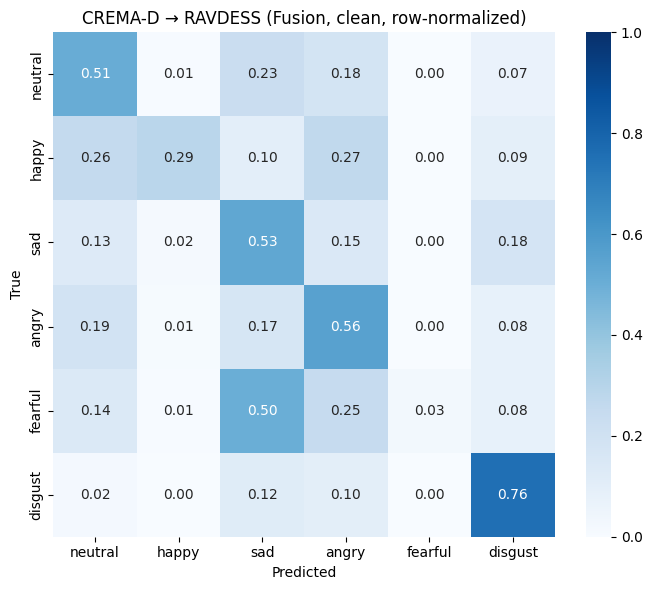

In [20]:
def plot_confusion_matrix(labels, preds, label_names, title, normalize='true'):
    """Plot a confusion matrix heatmap.
    normalize='true'  -> rows sum to 1 (recall per class) — best for comparing
                         classes with very different support, which RAVDESS has
                         (e.g. neutral=288 vs every other class=192).
    normalize=None    -> raw counts.
    """
    cm = confusion_matrix(labels, preds, normalize=normalize)
    fmt = '.2f' if normalize else 'd'

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=label_names, yticklabels=label_names,
                vmin=0, vmax=1 if normalize else None, cbar=True)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(
    all_labels, all_preds, label_names,
    title='CREMA-D → RAVDESS (Fusion, clean, row-normalized)',
    normalize='true'
)

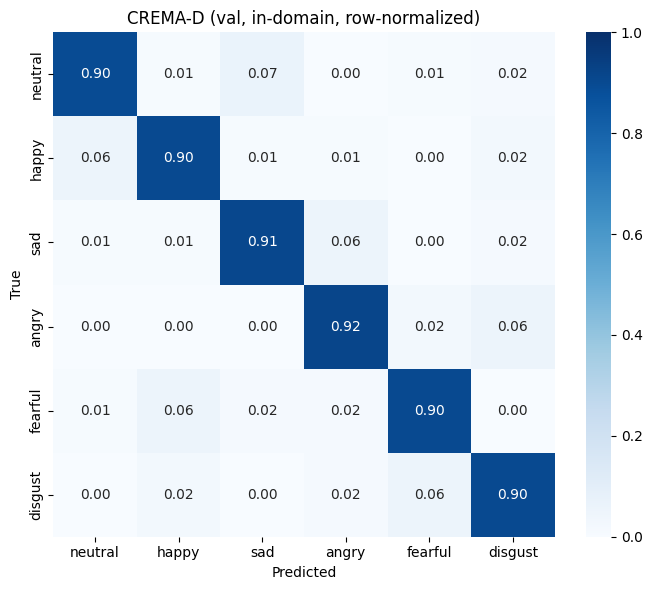

In [21]:
# In-domain comparison — regenerate predictions from val_loader (CREMA-D) using
# distinct variable names so this never silently reuses the RAVDESS predictions
# from the cell above (that's what happened last time: both plots used the same
# all_labels/all_preds still sitting in memory from the RAVDESS loop).
fusion_model.eval()
all_labels_crema, all_preds_crema = [], []
with torch.no_grad():
    for spec, face, label in val_loader:
        out, _ = fusion_model(spec.to(device), face.to(device))
        all_preds_crema.extend(out.argmax(1).cpu().tolist())
        all_labels_crema.extend(label.tolist())

plot_confusion_matrix(
    all_labels_crema, all_preds_crema, label_names,
    title='CREMA-D (val, in-domain, row-normalized)',
    normalize='true'
)

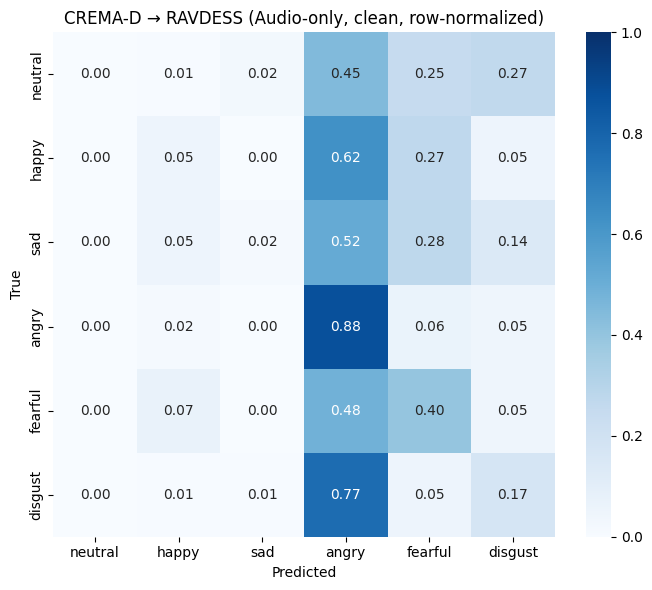

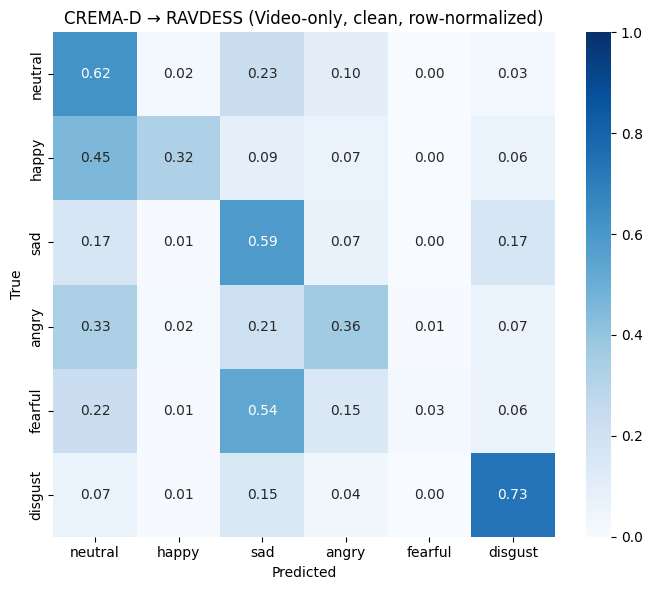

In [22]:
# Isolate which branch is responsible for the angry-collapse on RAVDESS:
# separate confusion matrices for the audio-only and video-only models.
audio_model.eval()
video_model.eval()

audio_labels_rav, audio_preds_rav = [], []
video_labels_rav, video_preds_rav = [], []
with torch.no_grad():
    for spec, face, label in ravdess_loader:
        spec, face = spec.to(device), face.to(device)

        a_out = audio_model(spec)
        audio_preds_rav.extend(a_out.argmax(1).cpu().tolist())
        audio_labels_rav.extend(label.tolist())

        v_out = video_model(face)
        video_preds_rav.extend(v_out.argmax(1).cpu().tolist())
        video_labels_rav.extend(label.tolist())

plot_confusion_matrix(
    audio_labels_rav, audio_preds_rav, label_names,
    title='CREMA-D → RAVDESS (Audio-only, clean, row-normalized)',
    normalize='true'
)

plot_confusion_matrix(
    video_labels_rav, video_preds_rav, label_names,
    title='CREMA-D → RAVDESS (Video-only, clean, row-normalized)',
    normalize='true'
)

In [23]:
# Per-class recall table: Audio / Video / Fusion, in-domain (CREMA-D) vs
# cross-domain (RAVDESS). Citable, compact summary of everything the
# confusion matrices above show visually.
from sklearn.metrics import recall_score

# Need audio/video predictions on CREMA-D val too (only fusion's were computed
# earlier, in cell 20) — same pattern as the RAVDESS audio/video loop above.
audio_model.eval()
video_model.eval()

audio_labels_crema, audio_preds_crema = [], []
video_labels_crema, video_preds_crema = [], []
with torch.no_grad():
    for spec, face, label in val_loader:
        spec, face = spec.to(device), face.to(device)

        a_out = audio_model(spec)
        audio_preds_crema.extend(a_out.argmax(1).cpu().tolist())
        audio_labels_crema.extend(label.tolist())

        v_out = video_model(face)
        video_preds_crema.extend(v_out.argmax(1).cpu().tolist())
        video_labels_crema.extend(label.tolist())


def per_class_recall(labels, preds):
    return recall_score(labels, preds, labels=list(range(len(label_names))), average=None)

rows = {
    'Audio (CREMA-D, in-domain)':   per_class_recall(audio_labels_crema, audio_preds_crema),
    'Video (CREMA-D, in-domain)':   per_class_recall(video_labels_crema, video_preds_crema),
    'Fusion (CREMA-D, in-domain)':  per_class_recall(all_labels_crema, all_preds_crema),
    'Audio (RAVDESS, cross-domain)':  per_class_recall(audio_labels_rav, audio_preds_rav),
    'Video (RAVDESS, cross-domain)':  per_class_recall(video_labels_rav, video_preds_rav),
    'Fusion (RAVDESS, cross-domain)': per_class_recall(all_labels, all_preds),
}

recall_table = pd.DataFrame(rows, index=label_names).T
recall_table['macro avg (UAR)'] = recall_table.mean(axis=1)
recall_table = recall_table.round(3)
recall_table

,neutral,happy,sad,angry,fearful,disgust,macro avg (UAR)
"Audio (CREMA-D, in-domain)",0.897,0.905,0.913,0.921,0.905,0.905,0.907
"Video (CREMA-D, in-domain)",0.907,0.897,0.913,0.921,0.905,0.905,0.908
"Fusion (CREMA-D, in-domain)",0.897,0.905,0.913,0.921,0.905,0.905,0.907
"Audio (RAVDESS, cross-domain)",0.000,0.052,0.016,0.875,0.396,0.172,0.252
"Video (RAVDESS, cross-domain)",0.618,0.323,0.589,0.365,0.026,0.734,0.442
"Fusion (RAVDESS, cross-domain)",0.510,0.286,0.531,0.557,0.026,0.755,0.444


In [24]:
print("audio == video:", audio_preds_crema == video_preds_crema)
print("audio == fusion:", audio_preds_crema == all_preds_crema)
print("video == fusion:", video_preds_crema == all_preds_crema)
print(len(audio_preds_crema), len(video_preds_crema), len(all_preds_crema))

audio == video: False
audio == fusion: True
video == fusion: False
737 737 737


In [25]:
print("audio_model is video_model:", audio_model is video_model)
print("audio_model is fusion_model:", audio_model is fusion_model)
print("video_model is fusion_model:", video_model is fusion_model)

audio_model is video_model: False
audio_model is fusion_model: False
video_model is fusion_model: False


In [26]:
# Diagnostic: are the three models actually holding different weights,
# and do they produce different raw outputs on the same batch?
import hashlib

def state_dict_hash(model):
    h = hashlib.md5()
    for k, v in model.state_dict().items():
        h.update(v.cpu().numpy().tobytes())
    return h.hexdigest()

print("audio_model hash: ", state_dict_hash(audio_model))
print("video_model hash: ", state_dict_hash(video_model))
print("fusion_model hash:", state_dict_hash(fusion_model))

# Grab one real batch and compare raw logits directly
spec, face, label = next(iter(val_loader))
spec, face = spec.to(device), face.to(device)

with torch.no_grad():
    a_out = audio_model(spec)
    v_out = video_model(face)
    f_out, alpha = fusion_model(spec, face)

print("\naudio logits[0]: ", a_out[0].cpu())
print("video logits[0]: ", v_out[0].cpu())
print("fusion logits[0]:", f_out[0].cpu())

print("\naudio argmax[:10]: ", a_out.argmax(1)[:10].cpu().tolist())
print("video argmax[:10]: ", v_out.argmax(1)[:10].cpu().tolist())
print("fusion argmax[:10]:", f_out.argmax(1)[:10].cpu().tolist())

audio_model hash:  1c37fe348f3910b01940e332b5bf8416
video_model hash:  5d40cef0c416de76ffdfb2d4e075406b
fusion_model hash: f6709c0e477c5d611efa23117e915c36

audio logits[0]:  tensor([ 0.2797, -1.9019, -3.7055,  5.1440, -2.4305, -1.7338])
video logits[0]:  tensor([-0.3940, -2.0336, -2.4030,  8.0643, -3.7724, -1.8122])
fusion logits[0]: tensor([-3.0916, -2.2897, -3.6897, 10.0456, -4.0247, -2.6586])

audio argmax[:10]:  [3, 5, 4, 1, 0, 2, 3, 3, 3, 5]
video argmax[:10]:  [3, 5, 4, 1, 0, 2, 3, 3, 3, 5]
fusion argmax[:10]: [3, 5, 4, 1, 0, 2, 3, 3, 3, 5]


In [27]:
# Is the gate saturating toward audio on clean in-domain data?
fusion_model.eval()
alphas_crema = []
with torch.no_grad():
    for spec, face, label in val_loader:
        _, alpha = fusion_model(spec.to(device), face.to(device))
        alphas_crema.extend(alpha.cpu().tolist())

import numpy as np
alphas_crema = np.array(alphas_crema)
print(f"CREMA-D (in-domain) alpha — mean: {alphas_crema.mean():.3f}, "
      f"min: {alphas_crema.min():.3f}, max: {alphas_crema.max():.3f}, "
      f"% > 0.95: {(alphas_crema > 0.95).mean()*100:.1f}%")

CREMA-D (in-domain) alpha — mean: 0.401, min: 0.069, max: 0.875, % > 0.95: 0.0%


In [28]:
fusion_model.eval()
audio_model.eval()
margins_audio, margins_fusion, alphas = [], [], []
with torch.no_grad():
    for spec, face, label in val_loader:
        spec, face = spec.to(device), face.to(device)
        a_out = audio_model(spec)
        f_out, alpha = fusion_model(spec, face)

        a_top2 = a_out.topk(2, dim=1).values
        f_top2 = f_out.topk(2, dim=1).values
        margins_audio.extend((a_top2[:, 0] - a_top2[:, 1]).cpu().tolist())
        margins_fusion.extend((f_top2[:, 0] - f_top2[:, 1]).cpu().tolist())
        alphas.extend(alpha.cpu().tolist())

import numpy as np
margins_audio, margins_fusion, alphas = map(np.array, (margins_audio, margins_fusion, alphas))
low_alpha = alphas < 0.3   # samples where fusion leans mostly on video
print(f"Mean audio margin (all):        {margins_audio.mean():.3f}")
print(f"Mean fusion margin (all):       {margins_fusion.mean():.3f}")
print(f"Mean audio margin (low-alpha):  {margins_audio[low_alpha].mean():.3f}")
print(f"Mean fusion margin (low-alpha): {margins_fusion[low_alpha].mean():.3f}")
print(f"Count low-alpha samples: {low_alpha.sum()} / {len(alphas)}")

Mean audio margin (all):        6.634
Mean fusion margin (all):       10.306
Mean audio margin (low-alpha):  6.222
Mean fusion margin (low-alpha): 10.430
Count low-alpha samples: 283 / 737
